In [5]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import json
import cv2
import matplotlib.patches as patches

sys.path.insert(0, "../../packages/python")

from data.class_imputation import *
import os

In [ ]:
scope = 'valid'

csv_path = f"/Users/joaquincibeira/INA/giar_ina_dev/data/data_roboflow_sam/{scope}/"
output_path = f"/Users/joaquincibeira/INA/giar_ina_dev/output/{scope}"
coco_json_path = f"/Users/joaquincibeira/INA/giar_ina_dev/data/roboflow/annotations_coco_{scope}.json"


with open(coco_json_path) as f:
    coco_data = json.load(f)

for f in os.listdir(csv_path):
    image_path = f"/Users/joaquincibeira/INA/giar_ina_dev/data/roboflow/{scope}/{f.split('.')[0]}.png"
    df = pd.read_csv(csv_path + '/' + f)
    image_filename = image_path.split("/")[-1]
    df = class_imputation(df, image_filename, coco_data)
    df.to_csv(output_path + '/' + f)


In [27]:
scope = 'valid'
csv_path = f"/Users/joaquincibeira/INA/giar_ina_dev/output/{scope}"
output_path = f"/Users/joaquincibeira/INA/giar_ina_dev/output/images/{scope}"

for f in os.listdir(csv_path):
    if not f.endswith(".csv"):
        continue

    image_path = f"/Users/joaquincibeira/INA/giar_ina_dev/data/roboflow/{scope}/{f.split('.')[0]}.png"
    df = pd.read_csv(os.path.join(csv_path, f))

    image = cv2.imread(image_path)
    if image is None:
        print(f"Image not found or unreadable: {image_path}")
        continue

    for i, row in df.iterrows():
        cls = row.get("assigned_class")
        if cls not in ["d", "nd"]:
            continue

        cell_id = row.get("cell_id")

        x, y, w, h = int(row["x"]), int(row["y"]), int(row["w"]), int(row["h"])
        crop = image[y:y+h, x:x+w]

        if crop.size == 0:
            continue

        crop_filename = f"{f.split('.')[0]}_{cell_id}.png"
        save_path = os.path.join(output_path, cls, crop_filename)
        cv2.imwrite(save_path, crop)

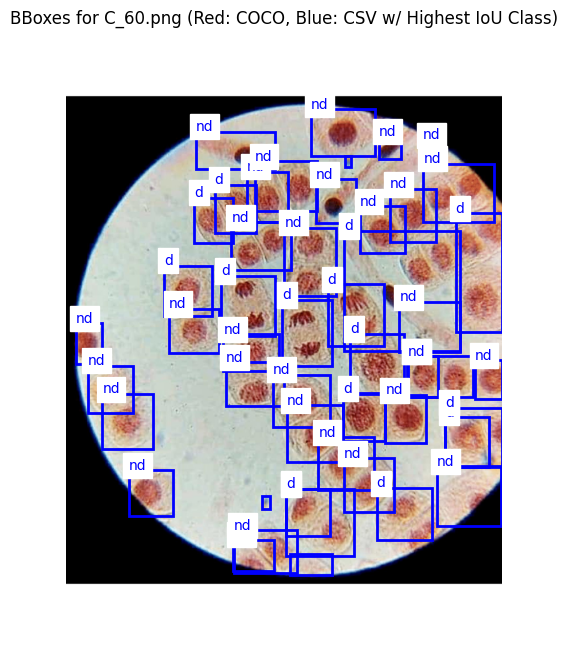

In [23]:


# Load CSV and filter overlapping inner boxes
csv_df = pd.read_csv('/Users/joaquincibeira/INA/giar_ina_dev/output/train/A_40.csv')

# Plot image
image = cv2.imread('/Users/joaquincibeira/INA/giar_ina_dev/data/roboflow/train/A_40.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.imshow(image)

# Draw CSV boxes in blue, label if class assigned
for _, row in csv_df.iterrows():
    rect = patches.Rectangle((row["x"], row["y"]), row["w"], row["h"], linewidth=2, edgecolor='blue', facecolor='none')
    ax.add_patch(rect)
    if pd.notna(row["assigned_class"]):
        ax.text(row["x"], row["y"] - 3, row["assigned_class"], color='blue', fontsize=10, backgroundcolor='white')

plt.title(f"BBoxes for {image_filename} (Red: COCO, Blue: CSV w/ Highest IoU Class)")
plt.axis('off')
plt.show()